In [1]:
import h5ify
import numpy as np
import matplotlib.pyplot as plt
from util import plot_corner, plot_multiple

%load_ext autoreload
%autoreload 2

In [2]:
from bilby.core.result import read_in_result
from bilby.core.result import plot_multiple as plot_multiple_bilby

r1 = read_in_result('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr10-far1e+00-nlive100/test_result.json')
r2 = read_in_result('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr15-far1e-05-nlive100/test_result.json')

In [ ]:
plot_multiple_bilby([r1, r2], filename='/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/compare.png');

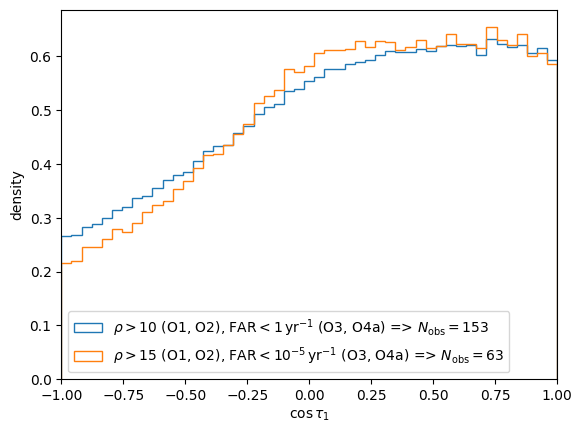

In [96]:
from data import get_data

bins = np.linspace(-1, 1, 50)

fig, ax = plt.subplots()

_, posteriors, _ = get_data(snr_thresh=10, far_thresh=1)
ax.hist(posteriors['cos_tilt_1'].flatten(), histtype='step', bins=bins, density=True, label=r'$\rho > 10$ (O1, O2), $\mathrm{FAR} < 1\,\rm yr^{-1}$ (O3, O4a) => $N_\mathrm{obs} = 153$')

_, posteriors, _ = get_data(snr_thresh=15, far_thresh=1e-5)
ax.hist(posteriors['cos_tilt_1'].flatten(), histtype='step', bins=bins, density=True, label=r'$\rho > 15$ (O1, O2), $\mathrm{FAR} < 10^{-5}\,\rm yr^{-1}$ (O3, O4a) => $N_\mathrm{obs} = 63$',);

ax.set_xlim(-1, 1)

ax.set_ylabel('density')
ax.set_xlabel(r'$\cos \tau_1$')

ax.legend()

fig.savefig('../../data/inference/cuts/concat-posterior-samples.png')

In [4]:
r1 = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr10-far1e+00-nlive100/posterior.h5')
r2 = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr15-far1e-05-nlive100/posterior.h5')

In [14]:
pr1 = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr10-far1e+00-nlive100/prior.h5')
pr2 = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr15-far1e-05-nlive100/prior.h5')

m1 = pr1['variance'] < 1
m2 = pr2['variance'] < 1

np.sum(m1), np.sum(m2)

(np.int64(8690), np.int64(1775))

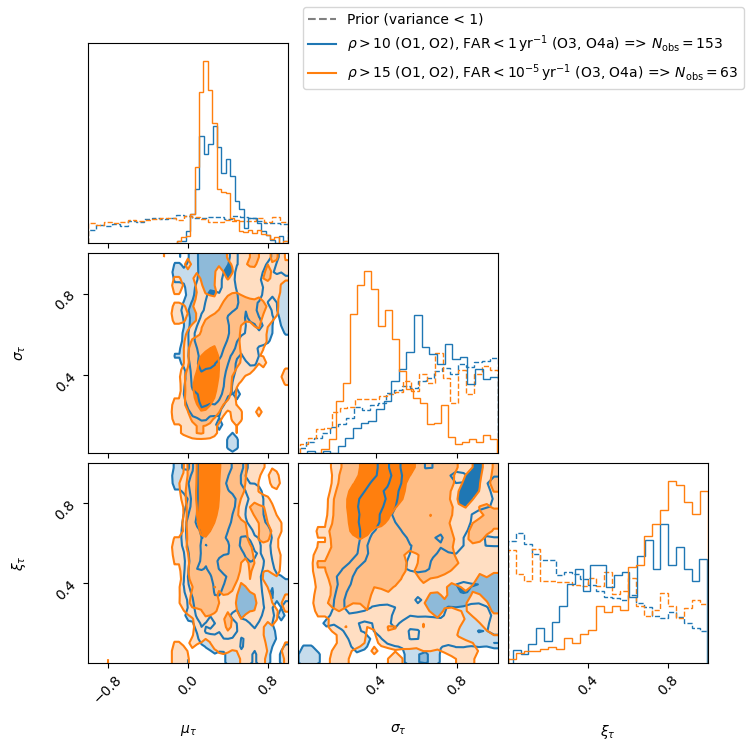

In [15]:
ks = dict(bins=25)

fig = plot_corner(
    np.column_stack([
        pr1['samples']['mu_spin'][m1],
        pr1['samples']['sigma_spin'][m1],
        pr1['samples']['xi_spin'][m1],
    ]),
    hist_kwargs=dict(linestyle='--', density=True),
    contour_kwargs=dict(linestyles=['--']),
    levels=(0, 0,),
    plot_datapoints=False,
    color='C0',
    labels=[r'$\mu_\tau$', r'$\sigma_\tau$', r'$\xi_\tau$'],
    **ks,
)

fig = plot_corner(
    np.column_stack([
        pr2['samples']['mu_spin'][m2],
        pr2['samples']['sigma_spin'][m2],
        pr2['samples']['xi_spin'][m2],
    ]),
    hist_kwargs=dict(linestyle='--', density=True),
    contour_kwargs=dict(linestyles=['--']),
    levels=(0, 0,),
    plot_datapoints=False,
    color='C1',
    fig=fig,
    **ks,
)

fig = plot_corner(
    np.column_stack([
        r1['samples']['mu_spin'],
        r1['samples']['sigma_spin'],
        r1['samples']['xi_spin'],
    ]),
    hist_kwargs=dict(linestyle='-', density=True),
    contour_kwargs=dict(linestyles=['-']),
    levels=(0.5, 0.9, 0.99),
    plot_datapoints=False,
    color='C0',
    fig=fig,
    **ks,
)

fig = plot_corner(
    np.column_stack([
        r2['samples']['mu_spin'],
        r2['samples']['sigma_spin'],
        r2['samples']['xi_spin'],
    ]),
    hist_kwargs=dict(linestyle='-', density=True),
    contour_kwargs=dict(linestyles=['-']),
    levels=(0.5, 0.9, 0.99),
    plot_datapoints=False,
    color='C1',
    fig=fig,
    **ks,
)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig.legend(
    handles=[
        Line2D([], [], color='grey', linestyle='--'),
        Line2D([], [], color='C0'),
        Line2D([], [], color='C1'),
    ],
    labels=[
        r'Prior (variance < 1)',
        r'$\rho > 10$ (O1, O2), $\mathrm{FAR} < 1\,\rm yr^{-1}$ (O3, O4a) => $N_\mathrm{obs} = 153$',
        r'$\rho > 15$ (O1, O2), $\mathrm{FAR} < 10^{-5}\,\rm yr^{-1}$ (O3, O4a) => $N_\mathrm{obs} = 63$'
    ]
)

fig.savefig('../../data/inference/cuts/corner-prior-tau.png')

In [ ]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from models import log_marg_iso_gauss_spin_tilt

test_tau = jnp.linspace(-1, 1, 500)

def step(_, x):
    return _, log_marg_iso_gauss_spin_tilt(
        test_tau,
        x['xi_spin'],
        x['sigma_spin'],
        x['mu_spin']
    ) 

_, ppd1 = jax.lax.scan(step, None, r1['samples'])
_, ppd2 = jax.lax.scan(step, None, r2['samples'])

In [83]:
from popsummary.popresult import PopulationResult

rpdir = '/home/noah.wolfe/lvk-data/GWTC-4/RP'
r = PopulationResult(f'{rpdir}/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5')
grid_lvk, rates = r.get_rates_on_grids('cos_tilt_1')

ppd_lvk = rates / np.trapezoid(rates, grid_lvk.squeeze(), axis=1)[:, None]
med = np.median(ppd_lvk, axis=0)
cil = np.quantile(ppd_lvk, 0.05, axis=0)
ciu = np.quantile(ppd_lvk, 0.95, axis=0)

r = PopulationResult(f'{rpdir}/BBHMassSpinRedshift_BSplineIID.h5')
grid_bspline, rates = r.get_rates_on_grids('p(cos_tilt)')
ppd_bspline = rates / np.trapezoid(rates, grid_bspline.squeeze(), axis=1)[:, None]
med_bs = np.median(ppd_bspline, axis=0)
cil_bs = np.quantile(ppd_bspline, 0.05, axis=0)
ciu_bs = np.quantile(ppd_bspline, 0.95, axis=0)

opening existing popsummary file: /home/noah.wolfe/lvk-data/GWTC-4/RP/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5
opening existing popsummary file: /home/noah.wolfe/lvk-data/GWTC-4/RP/BBHMassSpinRedshift_BSplineIID.h5


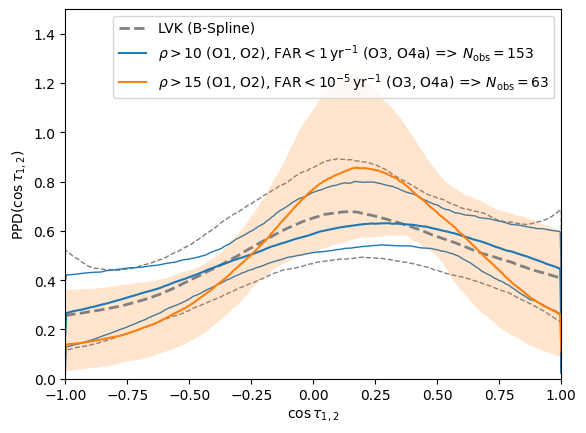

In [95]:
fig, ax = plt.subplots()

"""
ax.plot(
    grid_lvk.squeeze(),
    med,
    label=r'LVK',
    color='grey'
)
ax.fill_between(
    grid_lvk.squeeze(),
    cil,
    ciu,
    alpha=0.4,
    color='grey',
    linewidth=0
)
"""

ax.plot(
    grid_bspline.squeeze(),
    med_bs,
    label=r'LVK (B-Spline)',
    color='grey',
    linestyle='--',
    linewidth=2
)
ax.fill_between(
    grid_bspline.squeeze(),
    cil_bs,
    ciu_bs,
    edgecolor='grey',
    linestyle='--',
    facecolor='none'
)

ax.plot(
    test_tau,
    np.median(np.exp(ppd1), axis=0),
    label=r'$\rho > 10$ (O1, O2), $\mathrm{FAR} < 1\,\rm yr^{-1}$ (O3, O4a) => $N_\mathrm{obs} = 153$'
)
ax.fill_between(
    test_tau,
    np.quantile(np.exp(ppd1), 0.05, axis=0),
    np.quantile(np.exp(ppd1), 0.95, axis=0),
    edgecolor='C0',
    linestyle='-',
    facecolor='none'
)

ax.plot(
    test_tau,
    np.median(np.exp(ppd2), axis=0),
    label=r'$\rho > 15$ (O1, O2), $\mathrm{FAR} < 10^{-5}\,\rm yr^{-1}$ (O3, O4a) => $N_\mathrm{obs} = 63$',
    color='C1'
)
ax.fill_between(
    test_tau,
    np.quantile(np.exp(ppd2), 0.05, axis=0),
    np.quantile(np.exp(ppd2), 0.95, axis=0),
    alpha=0.2,
    color='C1',
    linewidth=0
)

ax.set_xlim(-1, 1)
ax.set_ylim(0, 1.5)

ax.set_xlabel(r'$\cos \tau_{1,2}$')
ax.set_ylabel(r'$\mathrm{PPD}(\cos \tau_{1,2})$')

ax.legend();

fig.savefig('../../data/inference/cuts/ppds.png')

In [ ]:
prior = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr15-far1e-05-nlive100/prior.h5')
mask = prior['variance'] < 1
prior['samples']['sigma_spin'][mask].min()

np.float64(0.024319085365055525)

: 

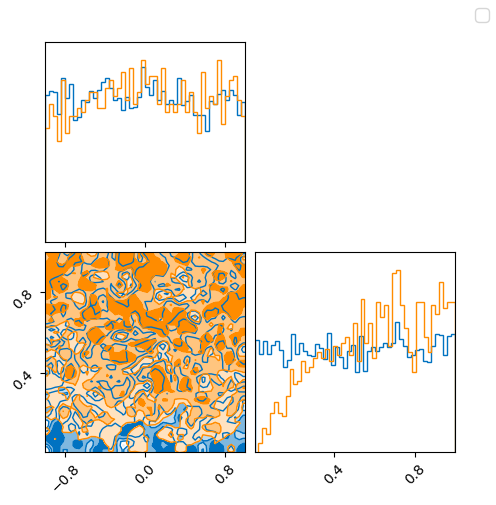

: 

In [ ]:
fig = plot_multiple(
    [
        np.column_stack([
            prior['samples']['mu_spin'],
            prior['samples']['sigma_spin'],
        ]),
        np.column_stack([
            prior['samples']['mu_spin'][mask],
            prior['samples']['sigma_spin'][mask],
        ])
    ]
)

In [ ]:
posterior = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr15-far1e-05-nlive100/posterior.h5')

: 

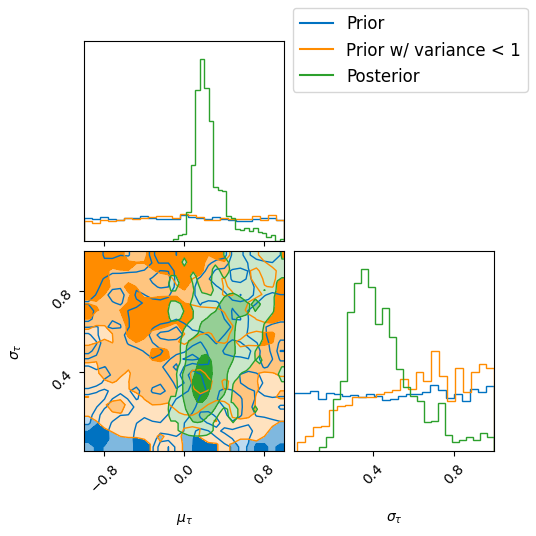

: 

In [ ]:
fig = plot_multiple(
    [
        np.column_stack([
            prior['samples']['mu_spin'],
            prior['samples']['sigma_spin'],
            #np.zeros(len(prior['variance'])), #prior['variance'][mask],
        ]),
        np.column_stack([
            prior['samples']['mu_spin'][mask],
            prior['samples']['sigma_spin'][mask],
            #prior['variance'][mask],
        ]),
        np.column_stack([
            posterior['samples']['mu_spin'],
            posterior['samples']['sigma_spin'],
            #posterior['variance']
        ])
    ],
    xs_labels=['Prior', 'Prior w/ variance < 1', 'Posterior'],
    labels=[r'$\mu_\tau$', r'$\sigma_\tau$'], #r'variance'],
    #levels=(0.5, 0.9,),
    bins=25
)

In [2]:
prior = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/cuts/snr10-far1e+00-nlive100/prior.h5')
mask = prior['variance'] < 1

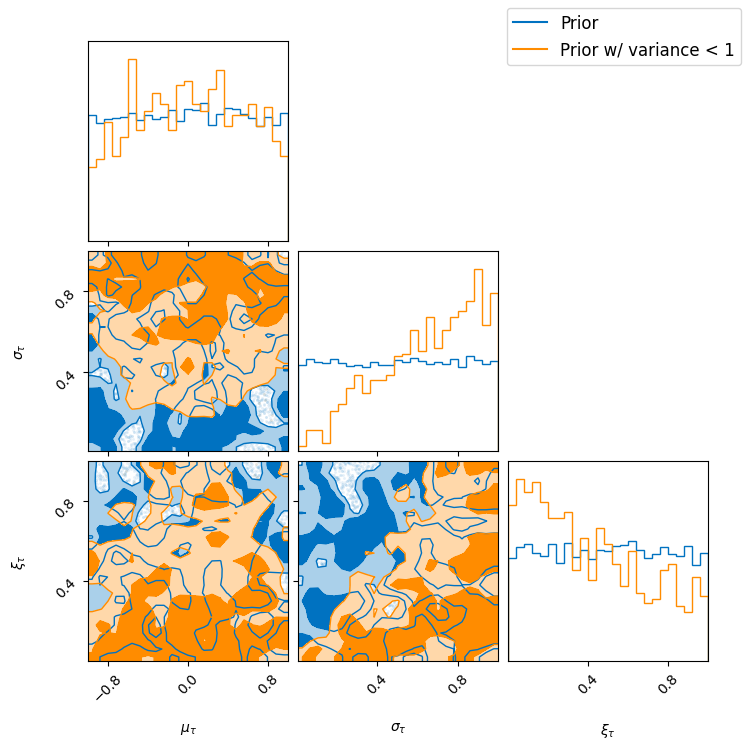

In [3]:
fig = plot_multiple(
    [
        np.column_stack([
            prior['samples']['mu_spin'],
            prior['samples']['sigma_spin'],
            prior['samples']['xi_spin'],
        ]),
        np.column_stack([
            prior['samples']['mu_spin'][mask],
            prior['samples']['sigma_spin'][mask],
            prior['samples']['xi_spin'][mask],
        ])
    ],
    bins=25,
    levels=(0.5, 0.9),
    labels=[r'$\mu_\tau$', r'$\sigma_\tau$', r'$\xi_\tau$'],
    xs_labels=['Prior', 'Prior w/ variance < 1']
)

In [ ]:
from data import get_data

: 

In [ ]:
_, post_snr10, injs_snr10 = get_data(snr_thresh=10, far_thresh=1)

: 

In [ ]:
events_snr15, post_snr15, injs_snr15 = get_data(snr_thresh=15, far_thresh=1e-5)

: 

In [ ]:
post_snr15['cos_tilt_1']

array([[ 0.20234196, -0.75975996, -0.8973669 , ..., -0.26159738,
        -0.09381314, -0.10048133],
       [-0.221256  ,  0.89485474,  0.45406357, ...,  0.0859352 ,
         0.09584614,  0.00314445],
       [-0.77085182,  0.77165314,  0.85774014, ...,  0.21554508,
         0.54389025, -0.46349806],
       ...,
       [-0.15943712, -0.14609384,  0.67909875, ...,  0.2275427 ,
        -0.59459781,  0.54585131],
       [-0.74656611,  0.41609077, -0.43578241, ...,  0.39404868,
         0.24222682, -0.39895124],
       [ 0.09157141,  0.57708618,  0.66638651, ...,  0.25305545,
        -0.20848466, -0.69025473]], shape=(63, 1993))

: 

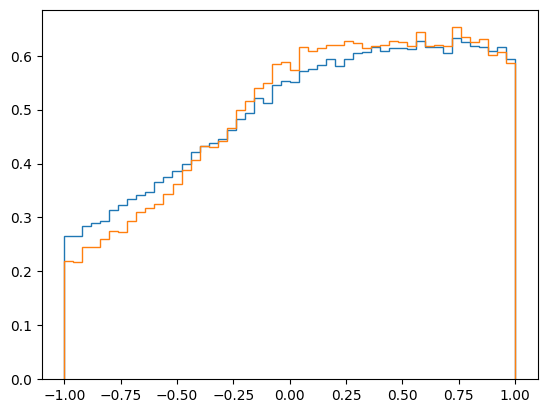

: 

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_snr10['cos_tilt_1'].flatten(), histtype='step', bins=50, density=True)
ax.hist(post_snr15['cos_tilt_1'].flatten(), histtype='step', bins=50, density=True);

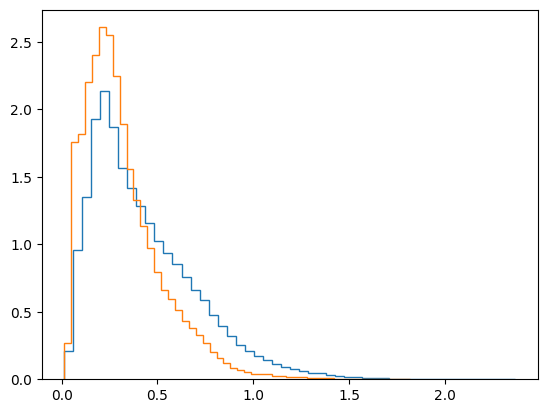

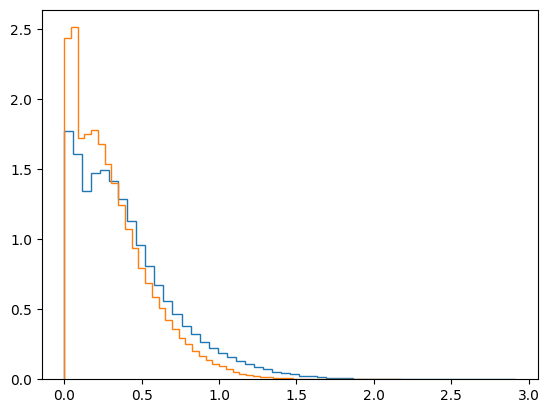

: 

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_snr10['redshift'].flatten(), histtype='step', bins=50, density=True)
ax.hist(post_snr15['redshift'].flatten(), histtype='step', bins=50, density=True);

fig, ax = plt.subplots()
ax.hist(injs_snr10['redshift'].flatten(), histtype='step', bins=50, density=True)
ax.hist(injs_snr15['redshift'].flatten(), histtype='step', bins=50, density=True);

In [ ]:
event_data = get_posteriors(load=True)

: 

In [ ]:
found = []

snr = 15
far = 1e-5

for e, s, f, c in zip(*event_data[1:]):
    if 'GWTC-1' in c:  # o1, o2
        found.append(s >= snr)
    else:
        found.append(f <= far)

found = np.array(found)


: 

In [ ]:
found

array([ True, False, False, False,  True, False, False,  True, False,
       False,  True,  True, False, False, False,  True,  True, False,
       False,  True, False,  True, False,  True, False,  True, False,
       False,  True, False, False,  True, False,  True,  True, False,
       False, False,  True, False, False,  True,  True, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True, False,  True, False,  True,  True, False, False, False,
       False,  True, False, False,  True,  True,  True,  True, False,
       False, False, False,  True,  True, False, False,  True, False,
       False, False, False, False, False, False, False, False,  True,
       False,  True, False, False, False,  True, False,  True, False,
       False,  True, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False,  True,  True, False,  True,
        True,  True,

: 

['GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2.1-confident',
 'GWTC-2

: 

In [ ]:
from data import get_posteriors
from data import get_injections

def cut_data(event_data, injections, snr=10, far=1):
    posteriors = event_data[0]
    event_snrs = event_data[2]
    event_fars = event_data[3]
    found = (event_fars < far) | (event_snrs > snr)
    posts = {k : v[found] for k, v in posteriors.items()}

    found = (injections['far'] < far) | (injections['snr'] > snr)
    injs = {k : v[found] for k, v in injections.items() if k not in ['time', 'total']}
    injs['total'] = injections['total']
    injs['time'] = injections['time']

    return posts, injs


def get_data(snr=10, far=1):
    event_data = get_posteriors(load=True)
    injections = get_injections(load=True)
    posteriors, injections = cut_data(event_data, injections, snr=snr, far=far)

    posteriors['mass_1'] = posteriors.pop('mass_1_source')

    injections['mass_1'] = injections.pop('mass_1_source')
    injections['total_generated'] = injections.pop('total')

    posteriors['log_prior'] = np.log(posteriors['prior'])
    injections['log_prior'] = np.log(injections['prior'])

    return posteriors, injections

: 

In [ ]:
get_posteriors(save=True)

84
153


  0%|          | 0/153 [00:00<?, ?it/s]/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/bilby/gw/cosmology.py:64: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import PC_SI as LAL_PC_SI
100%|██████████| 153/153 [01:15<00:00,  2.02it/s]


({'mass_1_source': array([[39.10021562, 33.78742232, 33.13574129, ..., 34.28421844,
          32.7276356 , 34.42362334],
         [39.75365942, 19.70802575, 24.69525385, ..., 26.70685344,
          21.29710039, 44.15406981],
         [10.03123369, 12.01631584, 11.01655076, ..., 21.51400073,
          10.54192177, 14.97643995],
         ...,
         [37.31908338, 42.71929663, 39.42811841, ..., 45.46815488,
          50.45819234, 40.35964563],
         [51.11866473, 58.37501644, 55.30076739, ..., 48.1541391 ,
          41.09999514, 93.81654613],
         [28.28806555, 35.03166305, 30.06847134, ..., 25.43298726,
          31.46430489, 33.14974673]], shape=(153, 1993)),
  'mass_ratio': array([[0.63250637, 0.923675  , 0.94777435, ..., 0.92852145, 0.96286961,
          0.81135264],
         [0.20778881, 0.78197999, 0.41604028, ..., 0.52602711, 0.74858137,
          0.23638688],
         [0.96220648, 0.69804548, 0.8873461 , ..., 0.26311006, 0.86245978,
          0.46775261],
         ...,
  

: 

In [ ]:
get_injections(save=True)

{'mass_1_source': array([45.15422679, 20.46347243, 31.49269517, ..., 22.27432032,
        65.88646499,  2.25242744], shape=(1065922,)),
 'mass_ratio': array([0.44799082, 0.81033314, 0.74996786, ..., 0.73068224, 0.66393557,
        0.85476055], shape=(1065922,)),
 'redshift': array([0.1502511 , 0.10812333, 0.183693  , ..., 0.38669392, 0.73260368,
        0.03056327], shape=(1065922,)),
 'a_1': array([0.16243093, 0.137373  , 0.02898515, ..., 0.99583277, 0.55638647,
        0.49881459], shape=(1065922,)),
 'a_2': array([0.3627992 , 0.28184632, 0.2437523 , ..., 0.95607815, 0.32076786,
        0.27731706], shape=(1065922,)),
 'cos_tilt_1': array([ 0.07403731,  0.72230954, -0.38512757, ...,  0.93889264,
         0.67981822, -0.2130991 ], shape=(1065922,)),
 'cos_tilt_2': array([ 0.71306297, -0.08572489,  0.94640479, ...,  0.88695208,
        -0.75479131, -0.3162247 ], shape=(1065922,)),
 'snr': array([13.23223315, 16.30352428, 13.64288273, ...,  0.        ,
         0.        ,  0.        ],

: 

: 

In [ ]:
import pandas as pd
df = pd.read_csv('/home/noah.wolfe/projects/tilts-and-kicks/data/lvk/all.csv')

: 

In [ ]:
r = h5ify.load(
    '../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors.h5'
)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

: 

In [ ]:
np.nanmax(df['far'])

np.float64(140.0)

: 

In [ ]:
df['version']

0      1
1      1
2      1
3      1
4      1
      ..
363    2
364    3
365    4
366    1
367    1
Name: version, Length: 368, dtype: int64

: 

In [ ]:
import pickle
import matplotlib.pyplot as plt

: 

In [ ]:
f = open('../../data/lvk/posteriors.pkl', 'rb')
posteriors = pickle.load(f)
f.close()

: 

In [ ]:
r = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors.h5')

: 

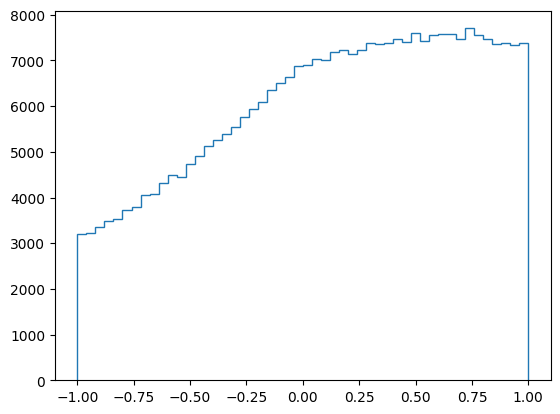

: 

In [ ]:
fig, ax = plt.subplots()
ax.hist(r['posteriors']['cos_tilt_1'].squeeze(), histtype='step', bins=50)

mask = 

In [ ]:
fig, ax = plt.subplots()
ax.hist(r['posteriors']['cos_tilt_1'], histtype='step', bins=50);

: 